In [1]:
"""

"""
import numpy as np
from skimage.metrics import structural_similarity as ssim_skimage
# from skimage.metrics import q
# from skimage.metrics import niqe
from imquality import brisque
from brisque import BRISQUE

from PIL import Image
import cv2
from sewar.full_ref import uqi as sewar_uqi
from torchmetrics.image import UniversalImageQualityIndex, QualityWithNoReference #, ni
from torchmetrics.image import StructuralSimilarityIndexMeasure
import torch
import torchvision.transforms as transforms

c:\Users\Eliaquim\anaconda3\envs\pdi\lib\site-packages\torchvision\io\image.py:13: UserWarning: Failed to load image Python extension: '[WinError 127] Não foi possível encontrar o procedimento especificado'If you don't plan on using image functionality from `torchvision.io`, you can ignore this warning. Otherwise, there might be something wrong with your environment. Did you have `libjpeg` or `libpng` installed before building `torchvision` from source?
  warn(


In [2]:
from torch.utils.data import Dataset

class CustomImageDataset(Dataset):
    def __init__(
        self,
        path_original="Pages/SAINTOGAN_PROSPER_ET_LE_MONSTRE_MARIN_016.jpg",
        path_label="Pages/SAINTOGAN_PROSPER_ET_LE_MONSTRE_MARIN_016.jpg",
        window=8,
    ):
        self.path_original = path_original
        self.path_label = path_label
        self.original = np.array(Image.open(self.path_original).convert("RGB"))
        self.label = np.array(Image.open(self.path_label).convert("RGB"))
        self.height, self.width, _ =  self.original.shape
        self.window = window
        self.length = (self.height - self.window) * (self.width - self.window)

    def __len__(self):
        return self.length
    
    def __getitem__(self, idx):
        h = int(idx // self.height)
        w = int(idx % self.height)

        if h>= self.height or w>= self.width:
            raise StopIteration

        original = transforms.ToTensor()(self.original[ h: h + self.window, w: w+ self.window, ...]) # [np.newaxis]
        label = transforms.ToTensor()(self.label[ h: h + self.window, w: w+ self.window, ...]) # [np.newaxis]

        return original, label #, h, w
    
    def __iter__(self):
        # self.index_current = 0
        return self
    
    def __next__(self):
        # self.index_current = 0
        #     if self.index_current <= 20:
        #   x = self.index_current
        #   self.index_current += 1
        for i in range(self.length):
            yield self.__getitem__(i)
        raise StopIteration

In [3]:
import tqdm
from torch.utils.data import DataLoader

def calc_uqi(img1, img2):
    """
    Calculate the Universal Quality Image Index (UQI) between two images.

    Parameters:
    img1 (numpy array): First image (reference image).
    img2 (numpy array): Second image (image to be compared).

    Returns:
    float: UQI value between -1 and 1.
    """
    assert img1.shape == img2.shape, "Images must have the same dimensions"
    
    N = img1.numel()
    # N_1 = torch.tensor(N - 1.) #, dtype=torch.float
    img1
    
    # Means
    mean1 = torch.mean(img1)
    mean2 = torch.mean(img2)
    
    # Variances and covariance
    var1 = (torch.sum((img1 - mean1) ** 2)/(N - 1)) ** (.5) 
    var2 = (torch.sum((img2 - mean2) ** 2)/(N - 1)) ** (.5)
    
    covar = torch.sum((img1 - mean1) * (img2 - mean2)) / (N - 1)
    
    # UQI calculation
    numerator = 4 * covar * mean1 * mean2
    denominator = (var1 + var2) * (mean1**2 + mean2**2)
    
    if denominator == 0:
        return 1 if numerator == 0 else 0
    
    uqi_value = numerator / denominator
    # uqi_value.backward(torch.tensor(1))

    return uqi_value

images = CustomImageDataset(
  path_original = "results/drive/cmeans/art/imgs/original/0000005.jpg.png",
  path_label = "results/drive/cmeans/art/imgs/20/0000005.jpg.png" 
)
i = 0

total = torch.zeros((3,))

# raise Exception
dl = DataLoader(images, 16, shuffle=False)

# value = next(iter(dl))
# img1,img2 = value
# print(img1.shape,img2.shape)
# qtd = 0
# try:
#     for img1, img2 in tqdm.tqdm(dl):
#         # print(img1.shape, img2.shape)
#         for chanel in range(3):
#             total[chanel] += calc_uqi(img1[:,chanel: chanel + 1,...], img2[:,chanel: chanel + 1,...])
#             qtd += img1.shape[0]
# except:
#     pass

# print(total)
# print(total/qtd)

In [4]:
# len(images), qtd

In [5]:
# a, b = next(iter(dl))
# ba = a.shape[0], 
# ba, b.shape

In [6]:
def indice_q(image1, image2, mean_result=False):
    def calc_uqi(img1, img2):
        """
        Calculate the Universal Quality Image Index (UQI) between two images.

        Parameters:
        img1 (numpy array): First image (reference image).
        img2 (numpy array): Second image (image to be compared).

        Returns:
        float: UQI value between -1 and 1.
        """
        assert img1.shape == img2.shape, "Images must have the same dimensions"
        
        N = img1.numel()
        # N_1 = torch.tensor(N - 1.) #, dtype=torch.float
        img1
        
        # Means
        mean1 = torch.mean(img1)
        mean2 = torch.mean(img2)
        
        # Variances and covariance
        var1 = (torch.sum((img1 - mean1) ** 2)/(N - 1)) ** (.5) 
        var2 = (torch.sum((img2 - mean2) ** 2)/(N - 1)) ** (.5)
        
        covar = torch.sum((img1 - mean1) * (img2 - mean2)) / (N - 1)
        
        # UQI calculation
        numerator = 4 * covar * mean1 * mean2
        denominator = (var1 + var2) * (mean1**2 + mean2**2)
        
        if denominator == 0:
            return 1 if numerator == 0 else 0
        
        uqi_value = numerator / denominator
        # uqi_value.backward(torch.tensor(1))

        return uqi_value
    
    def over_mapping(img1, img2, window = 8):
        _, _, heigh, width  = img1.shape

        quality_map  = torch.ones((heigh-(2*window), width-(2*window)))
        
        heigh -= window + 1
        width -= window + 1

        for h in range(window, heigh):
            for w in range(window, width):
                quality_map[h - window, w - window] += calc_uqi(img1[..., h: h + window, w: w+ window], img2[..., h: h + window, w: w+ window])


        if mean_result:
            return torch.sum(quality_map)/ quality_map.numel(), quality_map


        return torch.sum(quality_map)/ quality_map.numel()
 
    if not mean_result:
        return [over_mapping(image1[:,channel:channel + 1,... ], image2[:,channel:channel + 1,... ]) for channel in range(3)]
    
    return [over_mapping(image1, image2)]

In [ ]:
def indice_q_matlab(image1, image2, mean_result=False, window = 8): # , border_index=
    def calc_uqi(img1, img2):
        assert img1.shape == img2.shape, "Images must have the same dimensions"

        # img1 = cv2.copyMakeBorder(img1, 
        #     top = window//2,
        #     bottom = window//2,
        #     left = window//2,
        #     right = window//2,
        #     borderType=cv2.BORDER_CONSTANT, value=0)
        
        # img2 = cv2.copyMakeBorder(img2, 
        #     top = window//2,
        #     bottom = window//2,
        #     left = window//2,
        #     right = window//2,
        #     borderType=cv2.BORDER_CONSTANT, value=0)
        # cv2.filter2D(padded_img, ddepth=-1, kernel= np.ones((8,8)))

        N = window ** 2
        # float64
        ones = np.ones((window,window), dtype=np.float32) #/ N

        img1_sq = img1* img1
        img2_sq = img2* img2
        img12_sq = img1* img2

        # anchor: Point = ...,delta: float 
        # BORDER_REPLICATE


        img1_sum = cv2.filter2D(img1, -1, ones, borderType=cv2.BORDER_WRAP )
        img2_sum = cv2.filter2D(img2, -1, ones, borderType=cv2.BORDER_WRAP )

        img1_sq_sum = cv2.filter2D(img1_sq, -1, ones, borderType=cv2.BORDER_WRAP )
        img2_sq_sum = cv2.filter2D(img2_sq, -1, ones, borderType=cv2.BORDER_WRAP )
        img12_sq_sum = cv2.filter2D(img12_sq, -1, ones, borderType=cv2.BORDER_WRAP )

        
        img12_sum_mul = img1_sum * img2_sum

        img12_sq_sum_mul = img1_sum * img1_sum + img2_sum * img2_sum


        numerator = 4 * ((N*img12_sq_sum) - img12_sum_mul) * img12_sum_mul
        # numerator = 4 *(N*img12_sq_sum - img12_sum_mul)*img12_sum_mul
        denominator1 = N*(img1_sq_sum + img2_sq_sum) - img12_sq_sum_mul
        denominator = denominator1*img12_sq_sum_mul

        quality_map = np.ones(denominator.shape)

        # print((denominator1 == 0).shape)
        # print((img12_sq_sum_mul != 0).shape)
        # lambda
        # print(img12_sq_sum_mul.shape)

        index = np.logical_and((denominator1 == 0), (img12_sq_sum_mul != 0))
        quality_map[index] = 2*img12_sum_mul[index]/img12_sq_sum_mul[index]

        # index = (img12_sq_sum_mul == 0)
        # quality_map[index] = 0.

        index = (denominator != 0)
        quality_map[index] = numerator[index]/denominator[index]
        quality = np.mean(quality_map)

        if mean_result:
            return  quality, quality_map

        return quality
 
    if not mean_result:
        return [calc_uqi(image1[...,channel:channel + 1], image2[...,channel:channel + 1]) for channel in range(3)]
    
    return [calc_uqi(image1, image2)]

In [ ]:
img_path_original = "results/drive/cmeans/art/imgs/original/0leonardo-da-vinci_mona-lisa.jpg.png" #  
img_original = np.array(Image.open(img_path_original).convert("RGB"))

img_path_gaussian = "results/drive/cmeans/art/imgs/20/0leonardo-da-vinci_mona-lisa.jpg.png" #  
img_gaussian = np.array(Image.open(img_path_gaussian).convert("RGB"))

img_original_tensor = transforms.ToTensor()(img_original)[np.newaxis]#[:,:,:80:,:80]
img_gaussian_tensor = transforms.ToTensor()(img_gaussian)[np.newaxis]#[:,:,:80:,:80] 


#png
# original = np.array([0.52266, 0.58923, 0.44418]) # 10
original = np.array([0.69744, 0.76212, 0.51447]) # 20

#jpg
# original = np.array([0.52596, 0.51795, 0.45725,]) # 10
# original = np.array([0.69929, 0.68913, 0.62334]) # 20
 

borders = [
        cv2.BORDER_CONSTANT, 
        cv2.BORDER_REPLICATE, 
        cv2.BORDER_REFLECT, 
        cv2.BORDER_WRAP, 
        cv2.BORDER_REFLECT_101, 
        # cv2.BORDER_TRANSPARENT, 
        cv2.BORDER_REFLECT_101,  #/ BORDER_REFLECT101
        cv2.BORDER_DEFAULT,  #/ BORDER_DEFAULT
        cv2.BORDER_ISOLATED, 
] 
# len(borders)
img1 = np.array(img_original / 255) # , dtype=np.float64
img2 = np.array(img_gaussian / 255) # , dtype=np.float64
q = indice_q_matlab(img1, img2, window=8) # , border_index = i
s = np.abs(original - np.array(q))
print(f"Q mat: {i} - {np.array(q)} - {np.sum(s)} - {np.average(s)}")#/1.5
# for i in range(0, 50):
#     try:
#     except:
#         pass
#     # print(borders[i])

Q mat: 49 - [0.6978064  0.76245075 0.51534906] - 0.001576208733162665 - 0.0005254029110542217


In [82]:
borders

[0, 1, 2, 3, 4, 4, 4, 16]

In [ ]:
np.array(img_original / 255)

dtype('float64')

In [ ]:
# Q: [0.98452865 0.99423533 0.9782244 ]
# Q: [0.9840023  0.99408497 0.97786206]
# Q: [0.98354382 0.99388781 0.97763242]

In [77]:
import matplotlib.pyplot as plt
%matplotlib inline

def show_images(images):
    # imgs = []
    plt.figure(figsize=(20, 20))
    for i, image in enumerate(images):
        plt.subplot(len(images), 1, i + 1)
        plt.imshow(image)

In [ ]:
torch_uqi = UniversalImageQualityIndex(
    # kernel_size=(91,91), # 
    # sigma = (.9, .9),
    # reduction = "none" # ['elementwise_mean', 'sum', 'none'] | None  "elementwise_mean",
) # 

# for channel in range(img_original.shape[-1]):
#     q_alternative = torch_uqi(img_original_tensor[:,channel: channel + 1, :,:], 
#                                img_gaussian_tensor[:,channel: channel + 1, :,:])
#     print("torchmetrics.image.uqi", q_alternative.numpy())

img_original_gray = cv2.cvtColor(img_original, cv2.COLOR_RGB2GRAY)  
img_gaussian_gray = cv2.cvtColor(img_gaussian, cv2.COLOR_RGB2GRAY)  

# / 255
# / 255

for i in range(3):
    q_gray_mat = indice_q_matlab(
        image1 = img_original[...,i:i+1] / 255, 
        image2 = img_gaussian[...,i:i+1] / 255, 
        mean_result=True, 
        window = 8,
        #   border_index = cv2.BORDER_WRAP
    )

    img_original_gray_tensor = transforms.ToTensor()(img_original_gray)[np.newaxis]
    img_gaussian_gray_tensor = transforms.ToTensor()(img_gaussian_gray)[np.newaxis] 

    # q_gray = indice_q(image1=img_original_gray_tensor, image2=img_gaussian_gray_tensor, mean_result=True)

    q_alternative = torch_uqi(img_original_tensor[:, i:i+1, ...] , 
                                img_gaussian_tensor[:, i:i+1, ...] )  
    print(q_alternative,  q_gray_mat[0][0], ) # q_gray[0][0],

tensor(0.6588) 0.6978064022267307
tensor(0.6950) 0.7624507482153653
tensor(0.4635) 0.5153490582910666


In [85]:
q_gray_mat[0][0]

0.7799500613641049

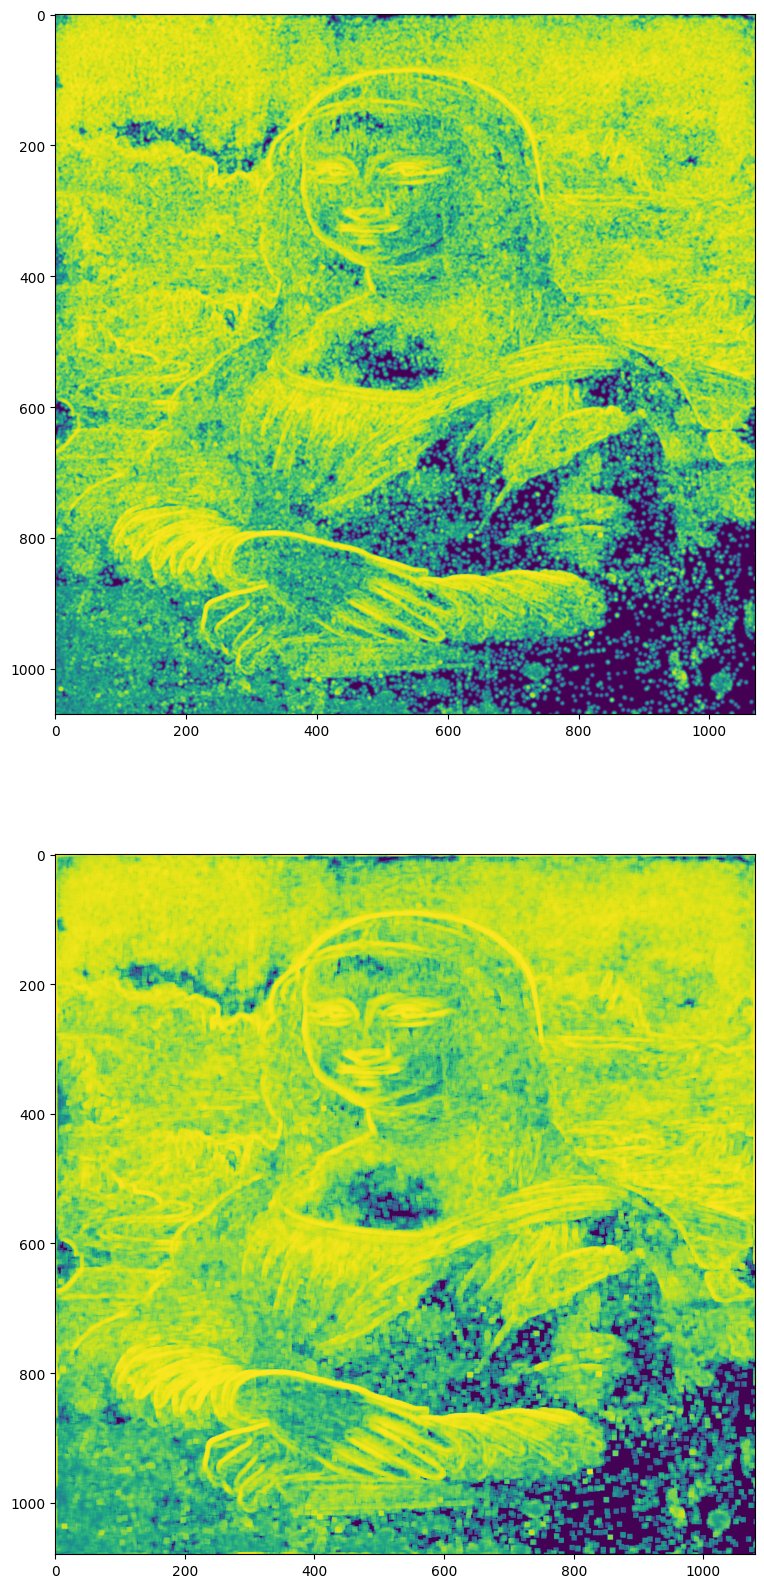

In [87]:
show_images([
  q_alternative.numpy()[0].transpose((1,2,0,)), 
  q_gray_mat[0][1][...,np.newaxis],
#   q_gray[0][1].numpy()[...,np.newaxis],
])

In [73]:
padded_img = cv2.copyMakeBorder(img_gaussian[...,0:1], 
    top = 4,
    bottom = 4,
    left = 4,
    right = 4,
    borderType=cv2.BORDER_CONSTANT, value=0)
cv2.filter2D(padded_img, ddepth=-1, kernel= np.ones((8,8)))

array([[ 20,  20,  46, ..., 255, 255, 170],
       [ 20,  20,  46, ..., 255, 255, 170],
       [ 40,  40,  86, ..., 255, 255, 255],
       ...,
       [100, 100, 206, ..., 255, 255, 255],
       [ 80,  80, 160, ..., 255, 255, 176],
       [ 60,  60, 120, ..., 255, 176,  88]], dtype=uint8)

In [53]:
a = np.array([True, False, True])
b = np.array([False, True, True])
a & b

array([False, False,  True])

In [25]:
375* 500

187500

In [24]:
img_gaussian.shape

(375, 500, 3)

In [ ]:


img_path_original = "results/drive/cmeans/art/imgs/original/0leonardo-da-vinci_mona-lisa.jpg.png" 
img_original = np.array(Image.open(img_path_original).convert("RGB"))

img_path_gaussian = "results/drive/cmeans/art/imgs/20/0leonardo-da-vinci_mona-lisa.jpg.png" 
img_gaussian = np.array(Image.open(img_path_gaussian).convert("RGB"))



torch_uqi = UniversalImageQualityIndex(
    # kernel_size=(91,91), # 
    # sigma = (.9, .9),
    reduction = "elementwise_mean" # ['elementwise_mean', 'sum', 'none'] | None  "elementwise_mean",
) # 

torch_ssim = StructuralSimilarityIndexMeasure()

img_original_tensor = transforms.ToTensor()(img_original)[np.newaxis]
img_gaussian_tensor = transforms.ToTensor()(img_gaussian)[np.newaxis] 

# img_original = img_original.astype(np.float32) / 255
# img_gaussian = img_gaussian.astype(np.float32) / 255

cores = [
    "vermelho",
    "verde",
    "azul",
]

# print(img_original.shape)
calc_brisque = BRISQUE(url=False) # **
# # print(brisque.calculate_features(Image.fromarray(img_original), kernel_size = 7, sigma = 7 / 6))
print(calc_brisque.score(img_original))
print(calc_brisque.score(img_gaussian))
# # print(cv2.quality.QualityBRISQUE.compute(img_original))
# exit(0)

for channel in range(img_original.shape[-1]):
    ssim_value, diff= ssim_skimage(img_original[:,:,channel], img_gaussian[:,:,channel], full=True)
    
    # PIQE

    q = sewar_uqi(img_original[:,:,channel], img_gaussian[:,:,channel])  
    q_alternative = torch_uqi(img_original_tensor[:,channel: channel + 1, :,:], 
                               img_gaussian_tensor[:,channel: channel + 1, :,:])
      
    torch_ssim_value = torch_ssim(img_original_tensor[:,channel: channel + 1, :,:], img_gaussian_tensor[:,channel: channel + 1, :,:])
    
    # PIQE_gaussian = qnr(img_gaussian_tensor[:,channel: channel + 1, :,:], {
    #     "ms": img_original_tensor[:,channel: channel + 1, :,:],
    #     "pan": img_original_tensor[:,channel: channel + 1, :,:],
    # })
    # # PIQE_gaussian = qnr(Image.fromarray(img_gaussian), Image.fromarray(img_gaussian))

    print(10*"#", cores[channel])
    # print(f"qnr: {PIQE_gaussian}")
    print("skimage.metrics.ssim", ssim_value)
    print("torchmetrics.image.ssim", torch_ssim_value.numpy())
    
    print("sewar.full_ref.sewar_uqi", q)
    print("torchmetrics.image.sewar_uqi", q_alternative.numpy())

img_original_gray = cv2.cvtColor(img_original, cv2.COLOR_RGB2GRAY)
img_gaussian_gray = cv2.cvtColor(img_gaussian, cv2.COLOR_RGB2GRAY)


img_original_gray_tensor = transforms.ToTensor()(img_original_gray)[np.newaxis]
img_gaussian_gray_tensor = transforms.ToTensor()(img_gaussian_gray)[np.newaxis] 

ssim_value, diff= ssim_skimage(img_original_gray, img_gaussian_gray, full=True)
torch_ssim_value = torch_ssim(img_original_gray_tensor, img_gaussian_gray_tensor)

# channel = 0
q = sewar_uqi(img_original, img_gaussian)  
q_alternative = torch_uqi(img_original_gray_tensor, 
                            img_gaussian_gray_tensor)  


calc_torch_uqi = lambda channel: torch_uqi(img_original_tensor[:,channel:channel+1,:,:], img_gaussian_tensor[:,channel:channel+1,:,:]).numpy().item()

uqi_value_teste = tuple(calc_torch_uqi(i) for i in range(3))

print("uqi_value_teste", uqi_value_teste)
# uqi_value = torch_uqi(image1, image2)  



print(10*"#", "cinza")
print("shape", img_original.shape, img_gaussian.shape)
print("skimage.metrics.ssim", ssim_value)
print("torchmetrics.image.ssim", torch_ssim_value.numpy())
print("sewar.full_ref.sewar_uqi", q)
print("torchmetrics.image.torch_uqi", q_alternative.numpy())
# print(uqi2(img_original[...,0], img_gaussian[...,0], mean_result=False))

img_original.size

# proporcionalmente tá parecido mas só fica proximo o valor quando aumenta o tamanho da janela do filtro
# 0005 => 51 , monalisa => +80